### Reproducing Figure 5c

Figure 5c visualizes the **quasi-potential landscape** inferred from the simulated annealing Monte Carlo sampling.

#### Input Data

The plotting script requires the metadata file:

```text
data/combined_metadata_finalstates.tsv
```

This file contains, for each barcode:

* `barcode` – cell barcode.
* `mds_component_1` and `mds_component_2` – coordinates in the MDS embedding derived from the TAD similarity matrix.
* `celltype` – cell type annotation.
* `energy` – computed Ising energy.
* `category` – cell category.
* `state` – whether the barcode is an original or generated state.
* `total_count_final_state` – the number of times the barcode was selected as the final state across all simulated annealing runs.
* `original_barcode` – the original barcode from which a generated barcode was derived.

#### Creating the Metadata File

If you have already completed the simulated annealing pipeline, you can create `combined_metadata_finalstates.tsv` using the `detailed_final_states` worksheet from:

```text
150n_e4_final_summary.xlsx
```

Merge this worksheet with the metadata containing the MDS coordinates, cell type annotations, and Ising energies for each barcode.

Alternatively, you can use the pre-generated file provided in the repository:

```text
data/combined_metadata_finalstates.tsv
```

#### Running the Plotting Script

Update the input file path:

```python
df = pd.read_csv("/path/to/combined_metadata_finalstates.tsv", sep="\t")
```

Then run the plotting script.

#### Adjustable Parameters

Several parameters control the construction of the quasi-potential landscape.

**Prior strength**

```python
alpha = 100
```

`alpha` controls the strength of the energy-based prior relative to the observed frequencies from the simulated annealing runs.

* Larger values place more weight on the Ising energy landscape.
* Smaller values place more weight on the observed final-state frequencies.

**Inverse temperature**

```python
beta = 1.0
```

The script automatically estimates the optimal value of `beta` by maximizing the likelihood of the observed final-state counts. In most cases, this parameter does not need to be modified manually.

**Kernel density estimation**

The quasi-potential landscape is estimated using a weighted Gaussian kernel density estimator. The kernel bandwidth is automatically selected by cross-validation:

```python
bandwidths = np.logspace(-2, 0, 20)
```

The optimal bandwidth is then used to construct the probability density and the corresponding quasi-potential landscape.

#### Output

The script:

* estimates the posterior probability of every barcode by combining the simulated annealing counts with the energy-based prior,
* constructs a weighted kernel density estimate in the MDS space,
* computes the quasi-potential landscape

[
U = -\log(\mathrm{density}),
]

* generates the three-dimensional landscape shown in **Figure 5c**,
* identifies the deepest attractor basin and several additional local attractors,
* saves the figure as a PDF,
* exports the posterior probabilities and additional analysis results to:

```text
landscape_analysis_results.tsv
```

Because the simulated annealing algorithm contains stochastic components, reproducing the pipeline may yield slightly different posterior probabilities and landscape topology. Nevertheless, the overall structure of the landscape and the biological interpretation remain consistent with those presented in the paper.


Total barcodes loaded: 3294
Barcodes with count > 0: 15
Total final state observations: 356
Estimated beta = 17.359

Prior probability range: 4.51e-10 to 1.51e-01

Top 10 barcodes by posterior probability:
               barcode  count    energy celltype  posterior
AAAGGGCAGATCTAAG_syn_2    163 -1.291359      OGC   0.374776
GTTATGGTCACTGGTA_syn_2     53 -1.328688      OGC   0.149338
ATGTCTTTCGCTAGTA_syn_3     50 -1.136512      ASC   0.110827
CAGTATGCACAAGTGG_syn_1     20 -1.088861      OPC   0.044375
GTTATGGTCACTGGTA_syn_2      0 -1.328688      OGC   0.033110
TCCATCGTCTTCATAC_syn_1     14 -1.119084      OPC   0.031572
TTCGTTAAGCATGTGG_syn_4     12 -1.127253      ASC   0.027319
GGAACTTTCTCTATCA_syn_1      0 -1.292509      OGC   0.017669
AAAGGGCAGATCTAAG_syn_2      0 -1.291359      OGC   0.017320
TAGTCCCTCTCCTTAA_syn_1      7 -1.069221      OGC   0.015717

Optimizing bandwidth...
Optimal bandwidth (scaled): 0.7848


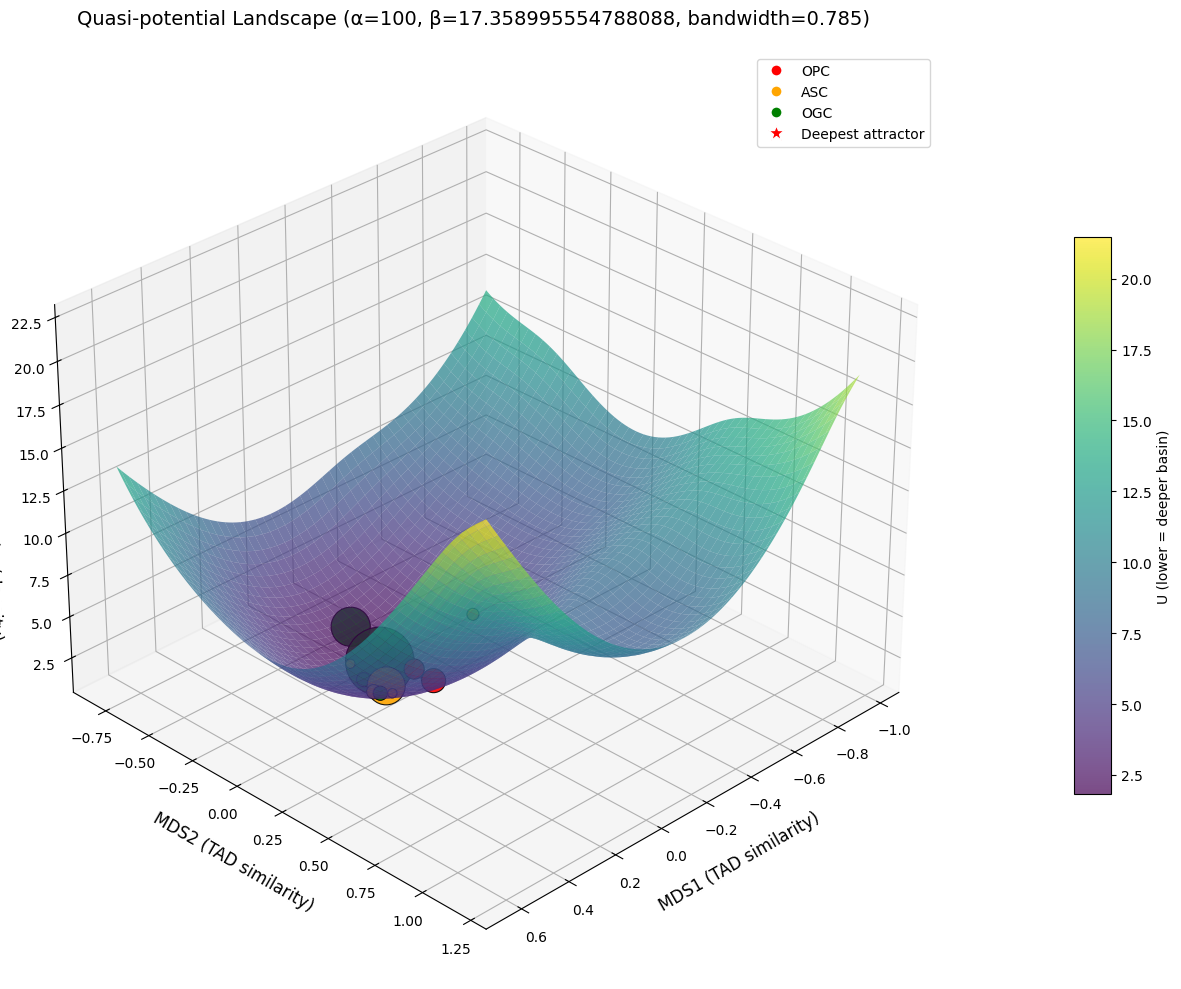


ATTRACTOR BASIN ANALYSIS
Deepest potential value: 1.8359
Deepest attractor at MDS coordinates: (0.032, -0.136)

Closest barcode to deepest attractor: AAAGGGCAGATCTAAG_syn_2
  Cell type: OGC
  Count: 163
  Energy: -1.2914

Top 5 deepest basins (by potential value):

Basin 1: U=1.8359 at (0.032, -0.136)
  Nearest barcode: AAAGGGCAGATCTAAG_syn_2
  Cell type: OGC
  Count: 163

Results saved to 'landscape_analysis_results.tsv'

SUMMARY STATISTICS
Number of barcodes analyzed: 3294
Number of visited barcodes: 15
Total runs: 356
Alpha (prior strength): 100
Beta (inverse temperature): 17.358995554788088
Optimal KDE bandwidth: 0.7848
Deepest potential value: 1.8359


In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Fri Apr 24 20:40:12 2026

@author: mozhganoroujlu
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from matplotlib import cm
from scipy.ndimage import minimum_filter, label
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

# ------------------------------------------------------------
# 1. Load your merged data
# ------------------------------------------------------------
# Use the file you created from the merge step
df = pd.read_csv('/Users/mozhganoroujlu/Desktop/SA/score/results/modif/generated/combined_metadata_finalstates.tsv', sep='\t')

# Rename columns to match the code expectations
df = df.rename(columns={
    'mds_component_1': 'mds1',
    'mds_component_2': 'mds2',
    'total_count_final_state': 'count',
    'original_barcode': 'core_sequence'
})

# Ensure count is integer and fill NAs
df['count'] = df['count'].fillna(0).astype(int)

# Remove any rows with missing MDS coordinates (if any)
df = df.dropna(subset=['mds1', 'mds2'])
print(f"Total barcodes loaded: {len(df)}")
print(f"Barcodes with count > 0: {(df['count'] > 0).sum()}")
print(f"Total final state observations: {df['count'].sum()}")

# ------------------------------------------------------------
# 2. Parameters (tune these based on your data)
# ------------------------------------------------------------
total_runs = df['count'].sum()  # Should be 350
beta = 1.0  # Inverse temperature - adjust if needed
alpha = 100  # Prior strength - increase to trust energies more, decrease to trust counts more


from scipy.optimize import minimize_scalar
def neg_log_likelihood(beta):
    probs = np.exp(-beta * df['energy']) / np.exp(-beta * df['energy']).sum()
    return -np.sum(df['count'][df['count'] > 0] * np.log(probs[df['count'] > 0] + 1e-10))
result = minimize_scalar(neg_log_likelihood, bracket=(0.1, 10))
beta = result.x
print(f"Estimated beta = {beta:.3f}")

# ------------------------------------------------------------
# 3. Compute prior probabilities from energies
# ------------------------------------------------------------
# Handle any missing energies
df['energy'] = df['energy'].fillna(df['energy'].median())

energies = df['energy'].values
prior_weights = np.exp(-beta * energies)
prior_probs = prior_weights / prior_weights.sum()

print(f"\nPrior probability range: {prior_probs.min():.2e} to {prior_probs.max():.2e}")

# ------------------------------------------------------------
# 4. Posterior probabilities (Dirichlet prior)
# ------------------------------------------------------------
observed_counts = df['count'].values
posterior_probs = (observed_counts + alpha * prior_probs) / (total_runs + alpha)

# Show top barcodes by posterior probability
print("\nTop 10 barcodes by posterior probability:")
top10 = df[['barcode', 'count', 'energy', 'celltype']].copy()
top10['posterior'] = posterior_probs
top10 = top10.sort_values('posterior', ascending=False).head(10)
print(top10.to_string(index=False))

# ------------------------------------------------------------
# 5. Prepare MDS coordinates (scale them for KDE)
# ------------------------------------------------------------
coords = df[['mds1', 'mds2']].values

# Scale coordinates to unit variance (important for KDE bandwidth)
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords)

# ------------------------------------------------------------
# 6. Weighted KDE with optimized bandwidth
# ------------------------------------------------------------
# Define bandwidth candidates (in scaled coordinate space)
bandwidths = np.logspace(-2, 0, 20)

# Use cross-validation to find optimal bandwidth
# Note: This might be slow for 900+ points; you can set a fixed bandwidth instead
print("\nOptimizing bandwidth...")
kde_cv = KernelDensity(kernel='gaussian')
param_grid = {'bandwidth': bandwidths}
grid_search = GridSearchCV(kde_cv, param_grid, cv=5, verbose=0)
grid_search.fit(coords_scaled, sample_weight=posterior_probs)

best_bandwidth = grid_search.best_params_['bandwidth']
print(f"Optimal bandwidth (scaled): {best_bandwidth:.4f}")

# Fit final KDE with optimal bandwidth
kde = KernelDensity(kernel='gaussian', bandwidth=best_bandwidth)
kde.fit(coords_scaled, sample_weight=posterior_probs)

# ------------------------------------------------------------
# 7. Create grid in original MDS space (for visualization)
# ------------------------------------------------------------
# Create grid in scaled space, then transform back for plotting
x_min_s, x_max_s = coords_scaled[:,0].min() - 0.5, coords_scaled[:,0].max() + 0.5
y_min_s, y_max_s = coords_scaled[:,1].min() - 0.5, coords_scaled[:,1].max() + 0.5
grid_x_s, grid_y_s = np.mgrid[x_min_s:x_max_s:100j, y_min_s:y_max_s:100j]
grid_coords_s = np.vstack([grid_x_s.ravel(), grid_y_s.ravel()]).T

# Evaluate log density in scaled space
log_density_s = kde.score_samples(grid_coords_s)
density_s = np.exp(log_density_s)
U_s = -log_density_s.reshape(grid_x_s.shape)

# Transform grid back to original MDS coordinates for plotting
# This step requires inverse scaling
grid_coords_original = scaler.inverse_transform(grid_coords_s)
grid_x = grid_coords_original[:,0].reshape(grid_x_s.shape)
grid_y = grid_coords_original[:,1].reshape(grid_y_s.shape)

# U is already computed in scaled space but the shape is same
U = U_s

# ------------------------------------------------------------
# 8. Plot the landscape
# ------------------------------------------------------------
fig = plt.figure(figsize=(14, 10))

# 3D Surface plot
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(grid_x, grid_y, U, cmap=cm.viridis, alpha=0.7, 
                        linewidth=0, antialiased=True, rasterized=True)

# Overlay visited barcodes (size proportional to count)
visited = df[df['count'] > 0].copy()
if len(visited) > 0:
    # Get coordinates for visited points
    visited_coords_scaled = scaler.transform(visited[['mds1', 'mds2']].values)
    log_dens_visited = kde.score_samples(visited_coords_scaled)
    U_visited = -log_dens_visited
    
    # Scale point sizes (count from 3 to 163)
    sizes = visited['count'] * 15
    
    # Color by celltype
    colors = {'OPC': 'red', 'ASC': 'orange', 'OGC': 'green'}
    point_colors = [colors.get(ct, 'blue') for ct in visited['celltype']]
    
    scatter = ax.scatter(visited['mds1'], visited['mds2'], U_visited,
                         s=sizes, c=point_colors, edgecolors='black', 
                         linewidth=0.8, alpha=0.9, zorder=10,
                         label='Visited final states (size ∝ count)')

# Mark global minimum (deepest attractor)
min_flat_idx = np.argmin(U)
min_idx_2d = np.unravel_index(min_flat_idx, U.shape)
deepest_x = grid_x[min_idx_2d]
deepest_y = grid_y[min_idx_2d]
deepest_U = U[min_idx_2d]
ax.scatter(deepest_x, deepest_y, deepest_U, color='red', s=200, marker='*',
           edgecolors='white', linewidth=1.5, zorder=20, label='Deepest attractor')

# Customize plot
ax.set_xlabel('MDS1 (TAD similarity)', fontsize=12, labelpad=10)
ax.set_ylabel('MDS2 (TAD similarity)', fontsize=12, labelpad=10)
ax.set_zlabel('Quasi-potential U = -log(density)', fontsize=12, labelpad=10)
ax.set_title(f'Quasi-potential Landscape (α={alpha}, β={beta}, bandwidth={best_bandwidth:.3f})', 
             fontsize=14, pad=20)

# Add colorbar
cbar = plt.colorbar(surf, ax=ax, shrink=0.6, aspect=15, pad=0.1)
cbar.set_label('U (lower = deeper basin)', fontsize=10)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', 
           label='OPC', markersize=8),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', 
           label='ASC', markersize=8),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', 
           label='OGC', markersize=8),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='red', 
           label='Deepest attractor', markersize=12)
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

# Adjust view angle for better visualization
ax.view_init(elev=30, azim=45)

plt.tight_layout()
plt.savefig('/Users/mozhganoroujlu/Desktop/MOZHGUN/cell_fate/hi_c/github/new_figs/quasi_potential_landscape.pdf', 
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.show()

# ------------------------------------------------------------
# 9. Additional analysis: Identify attractor basins
# ------------------------------------------------------------
# Find local minima in the potential
# Simple approach: find points lower than all neighbors
threshold = np.percentile(U, 10)  # Consider deepest 10% as potential basins

# Use minimum_filter to find local minima
# A point is a local minimum if it equals the minimum in its 3x3 neighborhood
local_min_mask = (U == minimum_filter(U, size=3))
local_min_indices = np.where(local_min_mask & (U < threshold))

print("\n" + "="*60)
print("ATTRACTOR BASIN ANALYSIS")
print("="*60)
print(f"Deepest potential value: {deepest_U:.4f}")
print(f"Deepest attractor at MDS coordinates: ({deepest_x:.3f}, {deepest_y:.3f})")

# Find barcode closest to deepest attractor
distances_to_deepest = cdist(coords, [[deepest_x, deepest_y]])
closest_idx = np.argmin(distances_to_deepest)
print(f"\nClosest barcode to deepest attractor: {df.iloc[closest_idx]['barcode']}")
print(f"  Cell type: {df.iloc[closest_idx]['celltype']}")
print(f"  Count: {df.iloc[closest_idx]['count']}")
print(f"  Energy: {df.iloc[closest_idx]['energy']:.4f}")

# Top 5 deepest basins
print("\nTop 5 deepest basins (by potential value):")
# Convert U to 1D and find the smallest values
U_flat = U.flatten()
grid_x_flat = grid_x.flatten()
grid_y_flat = grid_y.flatten()

# Get indices of smallest 5 values (avoiding duplicates that are too close)
sorted_indices = np.argsort(U_flat)[:50]  # Get top 50 candidates
unique_basins = []
for idx in sorted_indices:
    x_val, y_val = grid_x_flat[idx], grid_y_flat[idx]
    # Check if this is far enough from already selected basins
    if len(unique_basins) == 0 or all(np.sqrt((x_val-xb)**2 + (y_val-yb)**2) > 0.3 for xb, yb, _ in unique_basins):
        unique_basins.append((x_val, y_val, U_flat[idx]))
        if len(unique_basins) == 5:
            break

for i, (x_val, y_val, u_val) in enumerate(unique_basins, 1):
    # Find nearest barcode to this basin
    dist_to_basin = cdist(coords, [[x_val, y_val]])
    nearest_idx = np.argmin(dist_to_basin)
    print(f"\nBasin {i}: U={u_val:.4f} at ({x_val:.3f}, {y_val:.3f})")
    print(f"  Nearest barcode: {df.iloc[nearest_idx]['barcode']}")
    print(f"  Cell type: {df.iloc[nearest_idx]['celltype']}")
    print(f"  Count: {df.iloc[nearest_idx]['count']}")

# ------------------------------------------------------------
# 10. Save results (optional)
# ------------------------------------------------------------
# Add posterior probabilities to dataframe for future use
df['posterior_probability'] = posterior_probs
df.to_csv('landscape_analysis_results.tsv', sep='\t', index=False)
print("\n" + "="*60)
print(f"Results saved to 'landscape_analysis_results.tsv'")
print("="*60)

# Additional summary statistics
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"Number of barcodes analyzed: {len(df)}")
print(f"Number of visited barcodes: {(df['count'] > 0).sum()}")
print(f"Total runs: {total_runs}")
print(f"Alpha (prior strength): {alpha}")
print(f"Beta (inverse temperature): {beta}")
print(f"Optimal KDE bandwidth: {best_bandwidth:.4f}")
print(f"Deepest potential value: {deepest_U:.4f}")

